# **ENCS5342 Final Project: Part-of-Speech (POS) Tagging**
Course: ENCS5342 – Information Retrieval with Applications of NLP
University: Birzeit University
Faculty: Faculty of Engineering and Technology
Department: Department of Electrical and Computer Engineering

Instructor: Dr. Ahmad Shawahnah

---

Team Members
| Name | Student ID |
|---|---|
| Roaa Geith | 1210832 |
| Sara Kafena | 1210420 |
| Waad Ziadeh | 1220423|

---

Project Title
Part-of-Speech Tagging on the English Penn Treebank using Baseline and Neural Sequence Tagging Models

---

Selected Track
Track 1 – Default Project: Part-of-Speech (POS) Tagging


# **Notebook Structure**
This notebook is organized according to the required project structure:

1. Abstract
2. Introduction
3. Prior & Related Work
4. Model
5. Data
6. Experiments
7. Results
8. Analysis & Conclusion
9. AI Usage Statement
10. References

# **Abstract**

Part-of-Speech (POS) tagging is a fundamental sequence labeling task in Natural
Language Processing. The goal of this project is to build and evaluate POS tagging
models for English using the Penn Treebank dataset in CoNLL format. Each token is
assigned a joint POS tag formed by combining the coarse-grained and fine-grained
Penn Treebank POS tags, such as NOUN-NNP, VERB-VBD, and PRON-PRP.

In this project, we implement and compare three approaches. The first is a simple
Most Frequent Tag (MFT) baseline that assigns each word its most common tag from
the training set. The second is a Bidirectional GRU (BiGRU) neural sequence
tagging model. The third is a Bidirectional LSTM (BiLSTM) neural sequence tagging
model. All models are evaluated using token-level accuracy, per-class precision,
recall, and F1-score, as well as micro- and macro-averaged metrics.

The BiGRU achieved the highest development accuracy of 95.81%, while the BiLSTM
achieved 95.63% — both significantly outperforming the MFT baseline at 89.83%.
The BiLSTM showed a marginal advantage in Macro F1 (0.8501 vs 0.8456), suggesting
slightly better handling of rare tag classes.



# **Individual Contributions**

All three team members — Roaa Geith, Sara Kafena, and Waad Ziadeh — contributed
equally to all aspects of the project. This includes data loading and preprocessing,
model design and implementation, training and evaluation, result analysis, and
writing of all notebook sections. All decisions were made collaboratively throughout
the project.

# **Introduction**
Part-of-Speech tagging is the task of assigning a grammatical category to each word in a sentence. These categories include nouns, verbs, adjectives, adverbs, pronouns, determiners, prepositions, and other linguistic classes. POS tagging is an important step in many NLP systems because it provides useful syntactic information about the structure of a sentence.

Although POS tagging may look simple, it is challenging because the same word can have different tags depending on its context. For example, the word book can be a noun in the sentence read a book, but it can also be a verb in the sentence book a flight. Therefore, a good POS tagger should consider both the word itself and the surrounding context.

In this project, we focus on English POS tagging using the Penn Treebank dataset. The target output is a joint POS tag that combines both the coarse-grained universal POS tag and the fine-grained Penn Treebank POS tag. This makes the prediction task more detailed and more informative.

The main goals of this project are:

1. To load and preprocess POS tagging data in CoNLL format.
2. To create joint POS tags by combining coarse and fine POS labels.
3. To implement a simple baseline model for comparison.
4. To implement and compare two neural sequence tagging models: a BiGRU and a BiLSTM.
5. To evaluate the models using accuracy, precision, recall, and F1-score.
6. To analyze model errors, especially differences between frequent and rare POS tags.

# **Prior & Related Work**

Part-of-Speech tagging has been studied for decades as one of the foundational
tasks in Natural Language Processing. Early systems relied on rule-based methods
and probabilistic models such as Hidden Markov Models (HMMs), where the Viterbi
algorithm was used to find the most likely tag sequence given an observed word
sequence (Rabiner, 1989).

Later approaches introduced maximum-entropy models and SVMs with hand-crafted
features including word identity, prefixes, suffixes, capitalization, and
neighboring words, achieving strong results on the Penn Treebank benchmark.

The shift to neural approaches began with the work of Collobert et al. (2011),
who demonstrated that a unified neural architecture with minimal feature
engineering could achieve near state-of-the-art results across multiple NLP
tasks including POS tagging. Their work established the foundation for
end-to-end neural NLP pipelines.

Bidirectional LSTMs became the dominant approach for sequence labeling tasks.
Huang et al. (2015) proposed the BiLSTM-CRF model, which combines a
bidirectional LSTM with a Conditional Random Field (CRF) output layer, achieving
state-of-the-art results on POS tagging and Named Entity Recognition. This model
demonstrated that capturing both left and right context is essential for accurate
sequence labeling.

More recently, Transformer-based models such as BERT (Devlin et al., 2018) have
achieved near-perfect POS tagging accuracy on the Penn Treebank, with reported
accuracies above 97%. However, these models require large computational resources
and pre-training on massive corpora. In contrast, our work focuses on building
and comparing lightweight recurrent architectures from scratch, which provides
deeper insight into the modeling choices that drive performance.

Our project is most closely related to the BiLSTM-based approach of Huang et al.
(2015), but differs in that we also compare a BiGRU architecture and analyze
the effect of model complexity on both frequent and rare tag classes.

### References for this section
- Rabiner, L. R. (1989). A tutorial on hidden Markov models. *Proceedings of the IEEE*, 77(2), 257–286.
- Collobert, R., et al. (2011). Natural language processing (almost) from scratch. *Journal of Machine Learning Research*, 12, 2493–2537.
- Huang, Z., Xu, W., & Yu, K. (2015). Bidirectional LSTM-CRF models for sequence labeling. *arXiv:1508.01991*.
- Devlin, J., et al. (2018). BERT: Pre-training of deep bidirectional transformers for language understanding. *arXiv:1810.04805*.

# Model

This project compares three approaches for POS tagging:

1. A Most Frequent Tag (MFT) baseline model.
2. A Bidirectional GRU (BiGRU) neural sequence tagging model.
3. A Bidirectional LSTM (BiLSTM) neural sequence tagging model.

## Most Frequent Tag Baseline

The baseline model assigns each word the POS tag that appeared most frequently
with that word in the training set. If a word was not seen during training, the
model assigns the most common tag in the entire training data as a default tag.
This model requires no training in the neural sense and serves as a simple
reference point.

## BiGRU Model

The BiGRU model is a neural sequence labeling model. Each input word is converted
into a numerical ID, then passed through an embedding layer to obtain a dense
vector representation. These embeddings are processed by a bidirectional GRU,
which captures context from both directions of the sentence. A dropout layer is
applied for regularization, and a final linear layer maps the output to a
probability distribution over the possible joint POS tags.

Architecture:
Input → Word IDs → Embedding Layer → BiGRU → Dropout → Linear Layer → POS Tags

## BiLSTM Model

The BiLSTM model follows the exact same architecture as the BiGRU, but replaces
the GRU layer with an LSTM layer. The LSTM uses three gates (input, forget, output)
compared to the GRU's two gates (reset, update), giving it a larger number of
parameters and potentially greater capacity to model longer dependencies.

Architecture:
Input → Word IDs → Embedding Layer → BiLSTM → Dropout → Linear Layer → POS Tags

## Comparison of Neural Models

Both neural models share the following hyperparameters:
- Embedding dimension: 100
- Hidden dimension: 128 (256 total due to bidirectionality)
- Dropout probability: 0.3
- Output size: 46 (45 real tags + 1 padding label)
- Optimizer: Adam with learning rate 0.001 and L2 weight decay 1e-4
- Gradient clipping: max norm 1.0
- Early stopping: patience = 2 epochs

The key difference is the recurrent layer: BiGRU uses GRU cells while BiLSTM
uses LSTM cells. Comparing the two allows us to evaluate the trade-off between
model complexity and tagging performance.

In [1]:
import os
import random
import copy
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix
)

# **Data**
The dataset used in this project is the English Penn Treebank corpus provided in CoNLL format. Each sentence is represented as a block of token-level rows, and sentences are separated by blank lines.

For this project, we use the following columns:

Word Form: the actual token in the sentence.
Coarse-grained POS tag: the universal POS category.
Fine-grained POS tag: the Penn Treebank POS category.

The target label is a joint tag formed by combining the coarse-grained and fine-grained tags using a hyphen.

For example:

| Word | Coarse POS | Fine POS | Joint Tag |
|---|---|---|---|
| Collins | NOUN | NNP | NOUN-NNP |
| was | VERB | VBD | VERB-VBD |
| it | PRON | PRP | PRON-PRP |

The training set is used to train the models, while the development set is used for validation and intermediate evaluation.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving en-universal-dev.conll to en-universal-dev.conll
Saving en-universal-train.conll to en-universal-train.conll


In [3]:
os.listdir()

['.config',
 'en-universal-train.conll',
 'en-universal-dev.conll',
 'sample_data']

In [4]:
def read_conll_file(file_path):
    """
    Reads a CoNLL-format file and returns:

sentences: a list of tokenized sentences
tags: a list of joint POS tag sequences

    The joint POS tag is formed as:
    coarse POS + "-" + fine POS
    """

    sentences = []
    tags = []

    current_words = []
    current_tags = []

    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if line == "":
                if current_words:
                    sentences.append(current_words)
                    tags.append(current_tags)
                    current_words = []
                    current_tags = []
                continue

            columns = line.split("\t")

            if len(columns) < 5:
                continue

            word = columns[1]
            coarse_pos = columns[3]
            fine_pos = columns[4]

            joint_tag = coarse_pos + "-" + fine_pos

            current_words.append(word)
            current_tags.append(joint_tag)

    if current_words:
        sentences.append(current_words)
        tags.append(current_tags)

    return sentences, tags

In [5]:
train_path = "en-universal-train.conll"
dev_path = "en-universal-dev.conll"

train_sentences, train_tags = read_conll_file(train_path)
dev_sentences, dev_tags = read_conll_file(dev_path)

print("Number of training sentences:", len(train_sentences))
print("Number of development sentences:", len(dev_sentences))

Number of training sentences: 37840
Number of development sentences: 1992


In [6]:
print("Example sentence:")
print(train_sentences[0])

print("\nExample joint POS tags:")
print(train_tags[0])

Example sentence:
['In', 'an', 'Oct.', '19', 'review', 'of', '``', 'The', 'Misanthrope', "''", 'at', 'Chicago', "'s", 'Goodman', 'Theatre', '(', '``', 'Revitalized', 'Classics', 'Take', 'the', 'Stage', 'in', 'Windy', 'City', ',', "''", 'Leisure', '&', 'Arts', ')', ',', 'the', 'role', 'of', 'Celimene', ',', 'played', 'by', 'Kim', 'Cattrall', ',', 'was', 'mistakenly', 'attributed', 'to', 'Christina', 'Haag', '.']

Example joint POS tags:
['ADP-IN', 'DET-DT', 'NOUN-NNP', 'NUM-CD', 'NOUN-NN', 'ADP-IN', '.-``', 'DET-DT', 'NOUN-NN', ".-''", 'ADP-IN', 'NOUN-NNP', 'PRT-POS', 'NOUN-NNP', 'NOUN-NNP', '.-(', '.-``', 'VERB-VBN', 'NOUN-NNS', 'VERB-VBP', 'DET-DT', 'NOUN-NN', 'ADP-IN', 'NOUN-NNP', 'NOUN-NNP', '.-,', ".-''", 'NOUN-NN', 'CONJ-CC', 'NOUN-NNS', '.-)', '.-,', 'DET-DT', 'NOUN-NN', 'ADP-IN', 'NOUN-NNP', '.-,', 'VERB-VBN', 'ADP-IN', 'NOUN-NNP', 'NOUN-NNP', '.-,', 'VERB-VBD', 'ADV-RB', 'VERB-VBN', 'ADP-IN', 'NOUN-NNP', 'NOUN-NNP', '.-.']


In [7]:
def dataset_statistics(sentences, tags, split_name):
    num_sentences = len(sentences)
    num_tokens = sum(len(sentence) for sentence in sentences)

    tag_counter = Counter()
    sentence_lengths = []

    for sentence, sentence_tags in zip(sentences, tags):
        sentence_lengths.append(len(sentence))
        tag_counter.update(sentence_tags)

    print(f"{split_name} Dataset Statistics")
    print("=" * 50)
    print("Number of sentences:", num_sentences)
    print("Number of tokens:", num_tokens)
    print("Number of unique joint POS tags:", len(tag_counter))
    print("Average sentence length:", round(np.mean(sentence_lengths), 2))
    print("Maximum sentence length:", np.max(sentence_lengths))
    print("Minimum sentence length:", np.min(sentence_lengths))

    print("\nMost common joint POS tags:")
    for tag, count in tag_counter.most_common(10):
        print(f"{tag}: {count}")

    return tag_counter, sentence_lengths  # ← هاي الإضافة الوحيدة

In [8]:
train_tag_counter, train_lengths = dataset_statistics(train_sentences, train_tags, "Training")
print()
dev_tag_counter, dev_lengths = dataset_statistics(dev_sentences, dev_tags, "Development")

Training Dataset Statistics
Number of sentences: 37840
Number of tokens: 902902
Number of unique joint POS tags: 45
Average sentence length: 23.86
Maximum sentence length: 141
Minimum sentence length: 1

Most common joint POS tags:
NOUN-NN: 126176
ADP-IN: 102515
NOUN-NNP: 87033
DET-DT: 77723
ADJ-JJ: 58227
NOUN-NNS: 56900
.-,: 46317
.-.: 37506
NUM-CD: 34775
ADV-RB: 29382

Development Dataset Statistics
Number of sentences: 1992
Number of tokens: 47126
Number of unique joint POS tags: 45
Average sentence length: 23.66
Maximum sentence length: 79
Minimum sentence length: 1

Most common joint POS tags:
NOUN-NN: 6759
ADP-IN: 5347
NOUN-NNP: 4433
DET-DT: 4109
ADJ-JJ: 2990
NOUN-NNS: 2956
.-,: 2410
.-.: 1972
NUM-CD: 1793
ADV-RB: 1588


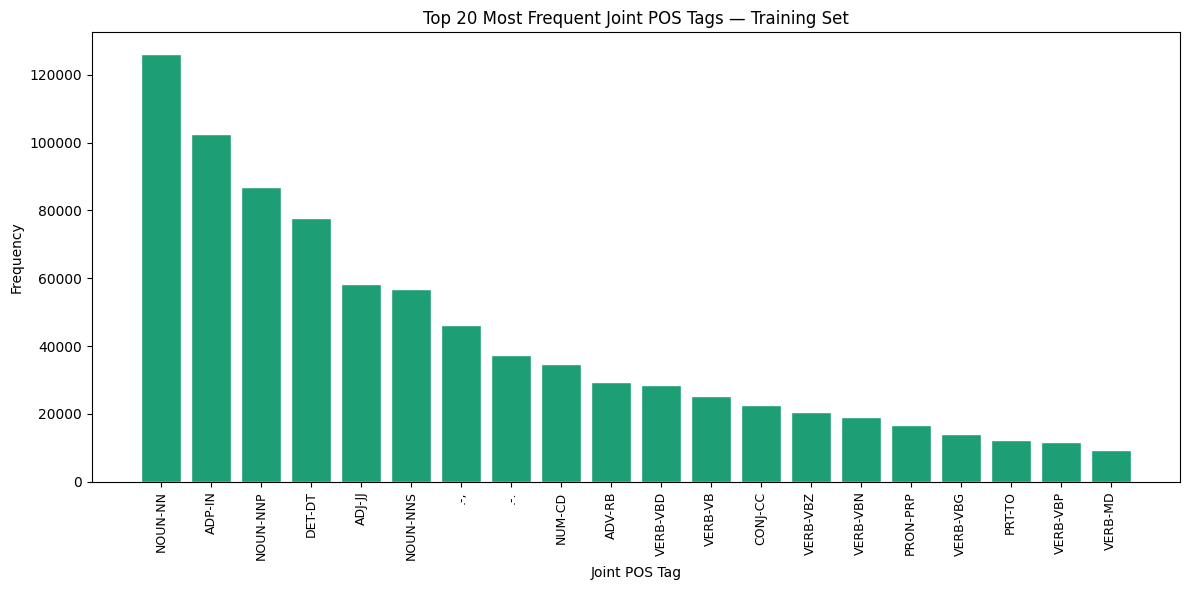

In [9]:
top_tags = train_tag_counter.most_common(20)

tag_names  = [tag   for tag, count in top_tags]
tag_counts = [count for tag, count in top_tags]

plt.figure(figsize=(12, 6))
plt.bar(tag_names, tag_counts, color="#1D9E75", edgecolor="white")
plt.xticks(rotation=90, fontsize=9)
plt.xlabel("Joint POS Tag")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Joint POS Tags — Training Set")
plt.tight_layout()
plt.show()

# **Experiments**

In this section, we implement and evaluate all three approaches for POS tagging.

## Experimental Setup

All models are trained and evaluated on the English Penn Treebank dataset in
CoNLL format. The training set contains 37,840 sentences and the development
set contains 1,992 sentences. All intermediate results are reported on the
development set.

The neural models are trained using the following setup:
- Batch size: 64
- Maximum epochs: 10
- Early stopping patience: 2 epochs
- Optimizer: Adam (lr=0.001, weight_decay=1e-4)
- Loss function: CrossEntropyLoss with ignore_index=0 for padding
- Gradient clipping: max_norm=1.0
- Random seed: 42 for reproducibility

## Evaluation Metrics

All models are evaluated using the following metrics:
- Token-level accuracy
- Per-class precision, recall, and F1-score for all 45 joint POS tags
- Micro-averaged precision, recall, and F1-score
- Macro-averaged precision, recall, and F1-score

The distinction between micro and macro averaging is important because the
Penn Treebank tag distribution is highly skewed. Micro-averaged scores are
dominated by frequent tags such as NOUN-NN and ADP-IN, while macro-averaged
scores give equal weight to all tags including rare ones such as X-LS and X-UH.

## Baseline Model

The MFT baseline memorizes the most frequent joint POS tag for each word in
the training set. For unseen words, it assigns the most common tag globally,
which is NOUN-NN. This baseline provides a simple reference point for
comparison with the neural models.

## Neural Models

Both the BiGRU and BiLSTM are trained from scratch using the same
infrastructure — the same Dataset, DataLoader, training loop, and evaluation
functions. The only difference between the two is the recurrent layer used.
This controlled setup ensures that any performance difference is attributable
to the architecture choice and not to other factors.

In [10]:
class MostFrequentTagger:
    def __init__(self):
        self.word_to_tag = {}
        self.default_tag = None

    def fit(self, sentences, tags):
        word_tag_counts = defaultdict(Counter)
        global_tag_counts = Counter()

        for sentence, sentence_tags in zip(sentences, tags):
            for word, tag in zip(sentence, sentence_tags):
                word_lower = word.lower()
                word_tag_counts[word_lower][tag] += 1
                global_tag_counts[tag] += 1

        self.default_tag = global_tag_counts.most_common(1)[0][0]

        for word, counter in word_tag_counts.items():
            self.word_to_tag[word] = counter.most_common(1)[0][0]

    def predict_sentence(self, sentence):
        predictions = []

        for word in sentence:
            word_lower = word.lower()

            if word_lower in self.word_to_tag:
                predictions.append(self.word_to_tag[word_lower])
            else:
                predictions.append(self.default_tag)

        return predictions

    def predict(self, sentences):
        return [self.predict_sentence(sentence) for sentence in sentences]

In [11]:
def flatten(nested_list):
    return [item for sublist in nested_list for item in sublist]


def evaluate_predictions(true_tags, predicted_tags, model_name):
    y_true = flatten(true_tags)
    y_pred = flatten(predicted_tags)

    accuracy = accuracy_score(y_true, y_pred)

    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="micro", zero_division=0
    )

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print(f"Results for {model_name}")
    print("=" * 60)
    print(f"Token-level Accuracy : {accuracy:.4f}")
    print(f"Micro  P / R / F1    : {micro_p:.4f} / {micro_r:.4f} / {micro_f1:.4f}")
    print(f"Macro  P / R / F1    : {macro_p:.4f} / {macro_r:.4f} / {macro_f1:.4f}")
    print()
    print("Per-class report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "model"   : model_name,
        "accuracy": accuracy,
        "micro_p" : micro_p, "micro_r": micro_r, "micro_f1": micro_f1,
        "macro_p" : macro_p, "macro_r": macro_r, "macro_f1": macro_f1
    }

In [12]:
baseline = MostFrequentTagger()
baseline.fit(train_sentences, train_tags)

train_predictions_baseline = baseline.predict(train_sentences)
dev_predictions_baseline = baseline.predict(dev_sentences)

print("Baseline training completed.")
print("Default tag for unseen words:", baseline.default_tag)
print("Number of known words:", len(baseline.word_to_tag))

Baseline training completed.
Default tag for unseen words: NOUN-NN
Number of known words: 38659


In [13]:
baseline_train_results = evaluate_predictions(
    train_tags,
    train_predictions_baseline,
    "Most Frequent Tag Baseline - Training Set"
)

baseline_dev_results = evaluate_predictions(
    dev_tags,
    dev_predictions_baseline,
    "Most Frequent Tag Baseline - Development Set"
)

Results for Most Frequent Tag Baseline - Training Set
Token-level Accuracy : 0.9172
Micro  P / R / F1    : 0.9172 / 0.9172 / 0.9172
Macro  P / R / F1    : 0.8477 / 0.8185 / 0.8196

Per-class report:
              precision    recall  f1-score   support

         .-#       1.00      1.00      1.00       138
         .-$       1.00      1.00      1.00      7021
        .-''       1.00      0.98      0.99      6588
         .-(       1.00      1.00      1.00      1308
         .-)       1.00      1.00      1.00      1314
         .-,       1.00      1.00      1.00     46317
         .-.       1.00      1.00      1.00     37506
         .-:       1.00      1.00      1.00      4546
        .-``       1.00      1.00      1.00      6748
      ADJ-JJ       0.85      0.91      0.88     58227
     ADJ-JJR       0.71      0.95      0.81      3073
     ADJ-JJS       0.80      0.99      0.89      1832
      ADP-IN       0.94      0.90      0.92    102515
      ADV-RB       0.94      0.85      0.89 

In [14]:
results_summary = pd.DataFrame([
    {
        "Model"    : "MFT Baseline",
        "Split"    : "Train",
        "Accuracy" : baseline_train_results["accuracy"],
        "Micro F1" : baseline_train_results["micro_f1"],
        "Macro F1" : baseline_train_results["macro_f1"],
    },
    {
        "Model"    : "MFT Baseline",
        "Split"    : "Dev",
        "Accuracy" : baseline_dev_results["accuracy"],
        "Micro F1" : baseline_dev_results["micro_f1"],
        "Macro F1" : baseline_dev_results["macro_f1"],
    },
])

results_summary = results_summary.round(4)
results_summary

,Model,Split,Accuracy,Micro F1,Macro F1
0,MFT Baseline,Train,0.9172,0.9172,0.8196
1,MFT Baseline,Dev,0.8983,0.8983,0.7806


# **Baseline Results Analysis**
The Most Frequent Tag baseline achieved a training accuracy of 91.72% and a development accuracy of 89.83%. This shows that many words in the dataset are strongly associated with a single POS tag, so a simple memorization-based approach can perform reasonably well. *The model assigns each word its most frequent joint POS tag from the training set, and for unseen words it uses the most common tag in the training data, which is usually NOUN-NN.*

However, the results also show that accuracy alone is not sufficient for evaluating POS tagging performance. The weighted average F1-score is high, around 0.90 on the development set, because frequent tags such as NOUN-NN, ADP-IN, DET-DT, and punctuation tags dominate the dataset. In contrast, the macro average F1-score is lower, around 0.78, because rare tags such as DET-PDT, X-FW, X-LS, and X-UH have very low or zero F1-scores. This indicates that the dataset is imbalanced and that the baseline performs much better on frequent tags than on rare ones.

The main limitation of this baseline is that it does not use sentence context. It always assigns the same tag to a word based on its most frequent training tag, even if the word can have different grammatical roles in different contexts. For example, a word may appear as a noun in one sentence and as a verb in another. This motivates the use of neural sequence tagging models — specifically a BiGRU and a BiLSTM — which can use both previous and following context when predicting the POS tag of each token.

# **BiLSTM & BiGRU Neural POS Tagging Model**
The second and third approaches are neural sequence tagging models: a Bidirectional Gated Recurrent Unit (BiGRU) and a Bidirectional Long Short-Term Memory network (BiLSTM). Unlike the baseline model, which memorizes the most frequent tag for each word, both neural models learn contextual representations of words. The BiGRU uses a simpler gating mechanism with fewer parameters, while the BiLSTM uses a more complex architecture that may capture longer dependencies. Comparing the two allows us to evaluate the trade-off between model complexity and performance.
Before training the models, we convert words and tags into numerical IDs, pad sentences to equal lengths within each batch, and use PyTorch DataLoader objects for batching.

In [15]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

def build_word_vocab(sentences, min_freq=1):
    word_counter = Counter()

    for sentence in sentences:
        for word in sentence:
            word_counter[word.lower()] += 1

    word_to_id = {
        PAD_TOKEN: 0,
        UNK_TOKEN: 1
    }

    for word, count in word_counter.items():
        if count >= min_freq:
            word_to_id[word] = len(word_to_id)

    return word_to_id


def build_tag_vocab(tags):
    tag_set = sorted(set(tag for sentence_tags in tags for tag in sentence_tags))

    tag_to_id = {PAD_TOKEN: 0}

    for tag in tag_set:
        tag_to_id[tag] = len(tag_to_id)

    id_to_tag = {idx: tag for tag, idx in tag_to_id.items()}

    return tag_to_id, id_to_tag


word_to_id = build_word_vocab(train_sentences, min_freq=1)
tag_to_id, id_to_tag = build_tag_vocab(train_tags)

print("Vocabulary size:", len(word_to_id))
print("Number of POS tags including PAD:", len(tag_to_id))
print("Number of real POS tags:", len(tag_to_id) - 1)

Vocabulary size: 38661
Number of POS tags including PAD: 46
Number of real POS tags: 45


In [17]:
class POSTaggingDataset(Dataset):
    def __init__(self, sentences, tags, word_to_id, tag_to_id):
        self.sentences = sentences
        self.tags = tags
        self.word_to_id = word_to_id
        self.tag_to_id = tag_to_id

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, index):
        sentence = self.sentences[index]
        sentence_tags = self.tags[index]

        word_ids = [
            self.word_to_id.get(word.lower(), self.word_to_id[UNK_TOKEN])
            for word in sentence
        ]

        tag_ids = [
            self.tag_to_id[tag]
            for tag in sentence_tags
        ]

        return torch.tensor(word_ids, dtype=torch.long), torch.tensor(tag_ids, dtype=torch.long)

In [18]:
def collate_batch(batch):
    word_sequences, tag_sequences = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in word_sequences], dtype=torch.long)
    max_length = lengths.max().item()

    padded_words = []
    padded_tags = []

    for words, tags in zip(word_sequences, tag_sequences):
        pad_length = max_length - len(words)

        padded_words.append(
            torch.cat([words, torch.zeros(pad_length, dtype=torch.long)])
        )

        padded_tags.append(
            torch.cat([tags, torch.zeros(pad_length, dtype=torch.long)])
        )

    padded_words = torch.stack(padded_words)
    padded_tags  = torch.stack(padded_tags)

    return padded_words, padded_tags, lengths

In [19]:
batch_size = 64

train_dataset = POSTaggingDataset(train_sentences, train_tags, word_to_id, tag_to_id)
dev_dataset   = POSTaggingDataset(dev_sentences,   dev_tags,   word_to_id, tag_to_id)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_batch
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch
)

print("Number of training batches:", len(train_loader))
print("Number of development batches:", len(dev_loader))

Number of training batches: 592
Number of development batches: 32


In [20]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim=100, hidden_dim=128, dropout=0.3):
        super(BiLSTMTagger, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim * 2, tagset_size)

    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        lstm_output, _ = self.lstm(embeddings)
        lstm_output = self.dropout(lstm_output)
        logits = self.fc(lstm_output)

        return logits

In [21]:
class BiGRUTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim=100, hidden_dim=128, dropout=0.3):
        super(BiGRUTagger, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim * 2, tagset_size)

    def forward(self, input_ids):
        embeddings = self.embedding(input_ids)
        gru_output, _ = self.gru(embeddings)
        gru_output = self.dropout(gru_output)
        logits = self.fc(gru_output)
        return logits

In [22]:
vocab_size  = len(word_to_id)
tagset_size = len(tag_to_id)

bilstm_model = BiLSTMTagger(
    vocab_size=vocab_size,
    tagset_size=tagset_size,
    embedding_dim=100,
    hidden_dim=128,
    dropout=0.3
).to(device)

bigru_model = BiGRUTagger(
    vocab_size=vocab_size,
    tagset_size=tagset_size,
    embedding_dim=100,
    hidden_dim=128,
    dropout=0.3
).to(device)

print("BiLSTM Model:")
print(bilstm_model)
print()
print("BiGRU Model:")
print(bigru_model)

BiLSTM Model:
BiLSTMTagger(
  (embedding): Embedding(38661, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=46, bias=True)
)

BiGRU Model:
BiGRUTagger(
  (embedding): Embedding(38661, 100, padding_idx=0)
  (gru): GRU(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=46, bias=True)
)


In [42]:
criterion = nn.CrossEntropyLoss(ignore_index=0)

bilstm_optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=0.001, weight_decay=1e-4)
bigru_optimizer  = torch.optim.Adam(bigru_model.parameters(),  lr=0.001, weight_decay=1e-4)

# Learning rate scheduler — ReduceLROnPlateau
bilstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    bilstm_optimizer, mode="min", factor=0.5, patience=1
)
bigru_scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    bigru_optimizer,  mode="min", factor=0.5, patience=1
)

The vocabulary built from the training set contains 38,661 unique tokens, including the special <PAD> and <UNK> tokens. The tag vocabulary contains 46 labels, consisting of 45 real joint POS tags plus one padding label. The training set was divided into 592 batches and the development set into 32 batches using a batch size of 64.
Two neural models are implemented and compared. The BiLSTM model consists of an embedding layer with 100-dimensional word embeddings, a bidirectional LSTM with hidden size 128, a dropout layer with probability 0.3, and a final linear layer. The BiGRU model follows the exact same architecture but replaces the LSTM layer with a GRU layer. Since both models are bidirectional, the output representation has size 256 for each token, which is then mapped to 46 possible output labels by the final linear layer.
Both models are trained using the Adam optimizer with a learning rate of 0.001 and L2 weight decay of 1e-4 to reduce overfitting.

A ReduceLROnPlateau learning rate scheduler is applied to each optimizer, halving the learning rate when the development loss stops improving

In [30]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for input_ids, labels, lengths in dataloader:
        input_ids = input_ids.to(device)
        labels    = labels.to(device)

        optimizer.zero_grad()

        outputs = model(input_ids)

        outputs = outputs.view(-1, outputs.shape[-1])
        labels  = labels.view(-1)

        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    all_true = []
    all_pred = []

    with torch.no_grad():
        for input_ids, labels, lengths in dataloader:
            input_ids = input_ids.to(device)
            labels    = labels.to(device)

            outputs = model(input_ids)

            loss = criterion(
                outputs.view(-1, outputs.shape[-1]),
                labels.view(-1)
            )

            total_loss += loss.item()

            predictions = torch.argmax(outputs, dim=-1)

            labels_flat      = labels.view(-1).cpu().numpy()
            predictions_flat = predictions.view(-1).cpu().numpy()

            for true_id, pred_id in zip(labels_flat, predictions_flat):
                if true_id != 0:
                    all_true.append(id_to_tag[true_id])
                    all_pred.append(id_to_tag[pred_id])

    accuracy = accuracy_score(all_true, all_pred)

    return total_loss / len(dataloader), accuracy, all_true, all_pred

In [31]:
def train_with_early_stopping(model, optimizer, scheduler, train_loader, dev_loader,
                               criterion, device, max_epochs=10, patience=2):
    train_losses      = []
    dev_losses        = []
    train_accuracies  = []
    dev_accuracies    = []

    best_dev_accuracy      = 0
    best_model_state       = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        dev_loss, dev_accuracy, dev_true, dev_pred = evaluate_model(model, dev_loader, criterion, device)
        _, train_accuracy, train_true, train_pred  = evaluate_model(model, train_loader, criterion, device)

        train_losses.append(train_loss)
        dev_losses.append(dev_loss)
        train_accuracies.append(train_accuracy)
        dev_accuracies.append(dev_accuracy)

        scheduler.step(dev_loss)

        print(f"Epoch {epoch + 1}/{max_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
        print(f"  Dev   Loss: {dev_loss:.4f}   | Dev   Acc: {dev_accuracy:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        if dev_accuracy > best_dev_accuracy:
            best_dev_accuracy  = dev_accuracy
            best_model_state   = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            print("  → New best model saved.")
        else:
            epochs_without_improvement += 1
            print(f"  → No improvement for {epochs_without_improvement} epoch(s).")

        print("-" * 50)

        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_state)
    print("Best Development Accuracy:", round(best_dev_accuracy, 4))

    return train_losses, dev_losses, train_accuracies, dev_accuracies

In [32]:
print("=" * 60)
print("Training BiGRU...")
print("=" * 60)
set_seed(42)
bigru_train_losses, bigru_dev_losses, bigru_train_accs, bigru_dev_accs = train_with_early_stopping(
    bigru_model, bigru_optimizer, bigru_scheduler, train_loader, dev_loader, criterion, device
)

print()
print("=" * 60)
print("Training BiLSTM...")
print("=" * 60)
set_seed(42)
bilstm_train_losses, bilstm_dev_losses, bilstm_train_accs, bilstm_dev_accs = train_with_early_stopping(
    bilstm_model, bilstm_optimizer, bilstm_scheduler, train_loader, dev_loader, criterion, device
)

Training BiGRU...
Epoch 1/10
  Train Loss: 0.7986 | Train Acc: 0.8414
  Dev   Loss: 0.5071   | Dev   Acc: 0.8404
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 2/10
  Train Loss: 0.4691 | Train Acc: 0.8909
  Dev   Loss: 0.3592   | Dev   Acc: 0.8905
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 3/10
  Train Loss: 0.3319 | Train Acc: 0.9265
  Dev   Loss: 0.2554   | Dev   Acc: 0.9227
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 4/10
  Train Loss: 0.2373 | Train Acc: 0.9486
  Dev   Loss: 0.1951   | Dev   Acc: 0.9411
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 5/10
  Train Loss: 0.1825 | Train Acc: 0.9603
  Dev   Loss: 0.1621   | Dev   Acc: 0.9502
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 6/10
  Train Loss: 0.1526 | Train Acc: 0.

In [33]:
#evaluation BiGRU
_, bigru_train_acc, bigru_train_true, bigru_train_pred = evaluate_model(
    bigru_model, train_loader, criterion, device
)
_, bigru_dev_acc, bigru_dev_true, bigru_dev_pred = evaluate_model(
    bigru_model, dev_loader, criterion, device
)

# evaluation BiLSTM
_, bilstm_train_acc, bilstm_train_true, bilstm_train_pred = evaluate_model(
    bilstm_model, train_loader, criterion, device
)
_, bilstm_dev_acc, bilstm_dev_true, bilstm_dev_pred = evaluate_model(
    bilstm_model, dev_loader, criterion, device
)

print("BiGRU  — Train Acc:", round(bigru_train_acc, 4), "| Dev Acc:", round(bigru_dev_acc, 4))
print("BiLSTM — Train Acc:", round(bilstm_train_acc, 4), "| Dev Acc:", round(bilstm_dev_acc, 4))

BiGRU  — Train Acc: 0.972 | Dev Acc: 0.9581
BiLSTM — Train Acc: 0.969 | Dev Acc: 0.9563


In [34]:
print("BiGRU Classification Report — Development Set")
print("=" * 60)
print(classification_report(bigru_dev_true, bigru_dev_pred, zero_division=0))

print("BiLSTM Classification Report — Development Set")
print("=" * 60)
print(classification_report(bilstm_dev_true, bilstm_dev_pred, zero_division=0))

BiGRU Classification Report — Development Set
              precision    recall  f1-score   support

         .-#       1.00      1.00      1.00         4
         .-$       1.00      1.00      1.00       351
        .-''       1.00      0.99      1.00       331
         .-(       1.00      1.00      1.00        58
         .-)       1.00      1.00      1.00        62
         .-,       1.00      1.00      1.00      2410
         .-.       1.00      1.00      1.00      1972
         .-:       1.00      1.00      1.00       226
        .-``       1.00      1.00      1.00       344
      ADJ-JJ       0.87      0.92      0.90      2990
     ADJ-JJR       0.82      0.94      0.87       165
     ADJ-JJS       0.93      0.97      0.94       115
      ADP-IN       0.98      0.98      0.98      5347
      ADV-RB       0.94      0.90      0.92      1588
     ADV-RBR       0.78      0.57      0.66        89
     ADV-RBS       1.00      0.33      0.50        15
     ADV-WRB       1.00      0.99  

In [35]:
bigru_train_results  = evaluate_predictions([bigru_train_true],  [bigru_train_pred],  "BiGRU  - Train")
bigru_dev_results    = evaluate_predictions([bigru_dev_true],    [bigru_dev_pred],    "BiGRU  - Dev")
bilstm_train_results = evaluate_predictions([bilstm_train_true], [bilstm_train_pred], "BiLSTM - Train")
bilstm_dev_results   = evaluate_predictions([bilstm_dev_true],   [bilstm_dev_pred],   "BiLSTM - Dev")

results_summary = pd.DataFrame([
    {
        "Model": "MFT Baseline", "Split": "Train",
        "Accuracy": baseline_train_results["accuracy"],
        "Micro F1": baseline_train_results["micro_f1"],
        "Macro F1": baseline_train_results["macro_f1"],
    },
    {
        "Model": "MFT Baseline", "Split": "Dev",
        "Accuracy": baseline_dev_results["accuracy"],
        "Micro F1": baseline_dev_results["micro_f1"],
        "Macro F1": baseline_dev_results["macro_f1"],
    },
    {
        "Model": "BiGRU", "Split": "Train",
        "Accuracy": bigru_train_results["accuracy"],
        "Micro F1": bigru_train_results["micro_f1"],
        "Macro F1": bigru_train_results["macro_f1"],
    },
    {
        "Model": "BiGRU", "Split": "Dev",
        "Accuracy": bigru_dev_results["accuracy"],
        "Micro F1": bigru_dev_results["micro_f1"],
        "Macro F1": bigru_dev_results["macro_f1"],
    },
    {
        "Model": "BiLSTM", "Split": "Train",
        "Accuracy": bilstm_train_results["accuracy"],
        "Micro F1": bilstm_train_results["micro_f1"],
        "Macro F1": bilstm_train_results["macro_f1"],
    },
    {
        "Model": "BiLSTM", "Split": "Dev",
        "Accuracy": bilstm_dev_results["accuracy"],
        "Micro F1": bilstm_dev_results["micro_f1"],
        "Macro F1": bilstm_dev_results["macro_f1"],
    },
])

results_summary = results_summary.round(4)
results_summary

Results for BiGRU  - Train
Token-level Accuracy : 0.9720
Micro  P / R / F1    : 0.9720 / 0.9720 / 0.9720
Macro  P / R / F1    : 0.8878 / 0.8619 / 0.8688

Per-class report:
              precision    recall  f1-score   support

         .-#       1.00      1.00      1.00       138
         .-$       1.00      1.00      1.00      7021
        .-''       1.00      1.00      1.00      6588
         .-(       1.00      1.00      1.00      1308
         .-)       1.00      1.00      1.00      1314
         .-,       1.00      1.00      1.00     46317
         .-.       1.00      1.00      1.00     37506
         .-:       1.00      1.00      1.00      4546
        .-``       1.00      1.00      1.00      6748
      ADJ-JJ       0.92      0.95      0.94     58227
     ADJ-JJR       0.83      0.94      0.88      3073
     ADJ-JJS       0.94      0.95      0.95      1832
      ADP-IN       0.98      0.99      0.99    102515
      ADV-RB       0.94      0.92      0.93     29382
     ADV-RBR     

,Model,Split,Accuracy,Micro F1,Macro F1
0,MFT Baseline,Train,0.9172,0.9172,0.8196
1,MFT Baseline,Dev,0.8983,0.8983,0.7806
2,BiGRU,Train,0.9720,0.9720,0.8688
3,BiGRU,Dev,0.9581,0.9581,0.8447
4,BiLSTM,Train,0.9690,0.9690,0.8617
5,BiLSTM,Dev,0.9563,0.9563,0.8501


# **Results Summary Analysis**

The results table shows a clear progression across the three models.
Both neural models significantly outperform the MFT baseline on all metrics.
Interestingly, the BiGRU achieves slightly higher accuracy and Micro F1 than
the BiLSTM (95.81% vs 95.63%), while the BiLSTM achieves a marginally higher
Macro F1 (0.8501 vs 0.8447), suggesting it handles rare tags slightly better.
The gap between Micro and Macro F1 persists across all models, indicating that
rare tags such as X-FW, X-LS, X-SYM, and X-UH remain challenging regardless
of model complexity.

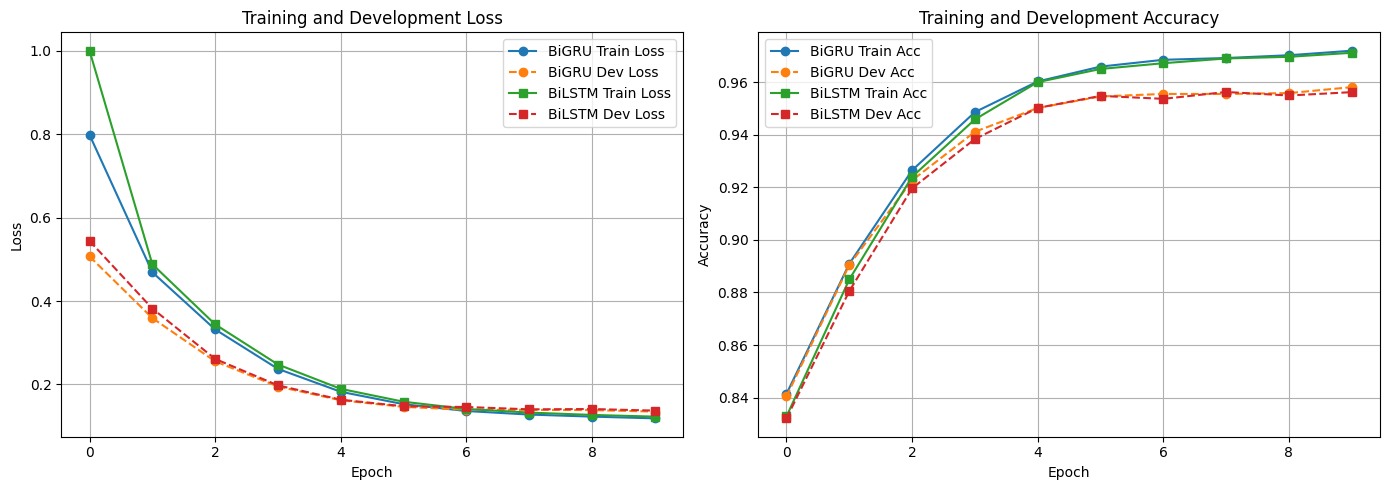

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(bigru_train_losses,  marker="o", label="BiGRU Train Loss")
axes[0].plot(bigru_dev_losses,    marker="o", label="BiGRU Dev Loss",   linestyle="--")
axes[0].plot(bilstm_train_losses, marker="s", label="BiLSTM Train Loss")
axes[0].plot(bilstm_dev_losses,   marker="s", label="BiLSTM Dev Loss",  linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Development Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(bigru_train_accs,  marker="o", label="BiGRU Train Acc")
axes[1].plot(bigru_dev_accs,    marker="o", label="BiGRU Dev Acc",   linestyle="--")
axes[1].plot(bilstm_train_accs, marker="s", label="BiLSTM Train Acc")
axes[1].plot(bilstm_dev_accs,   marker="s", label="BiLSTM Dev Acc",  linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Development Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# **Confusion Matrix**

To better understand the types of errors made by the neural models, we generate confusion matrices for both the BiGRU and BiLSTM on the development set. Since the full tag set contains 45 joint POS tags, the complete confusion matrix can be difficult to read. Therefore, we focus on the top 15 most frequent POS tags in the development set.

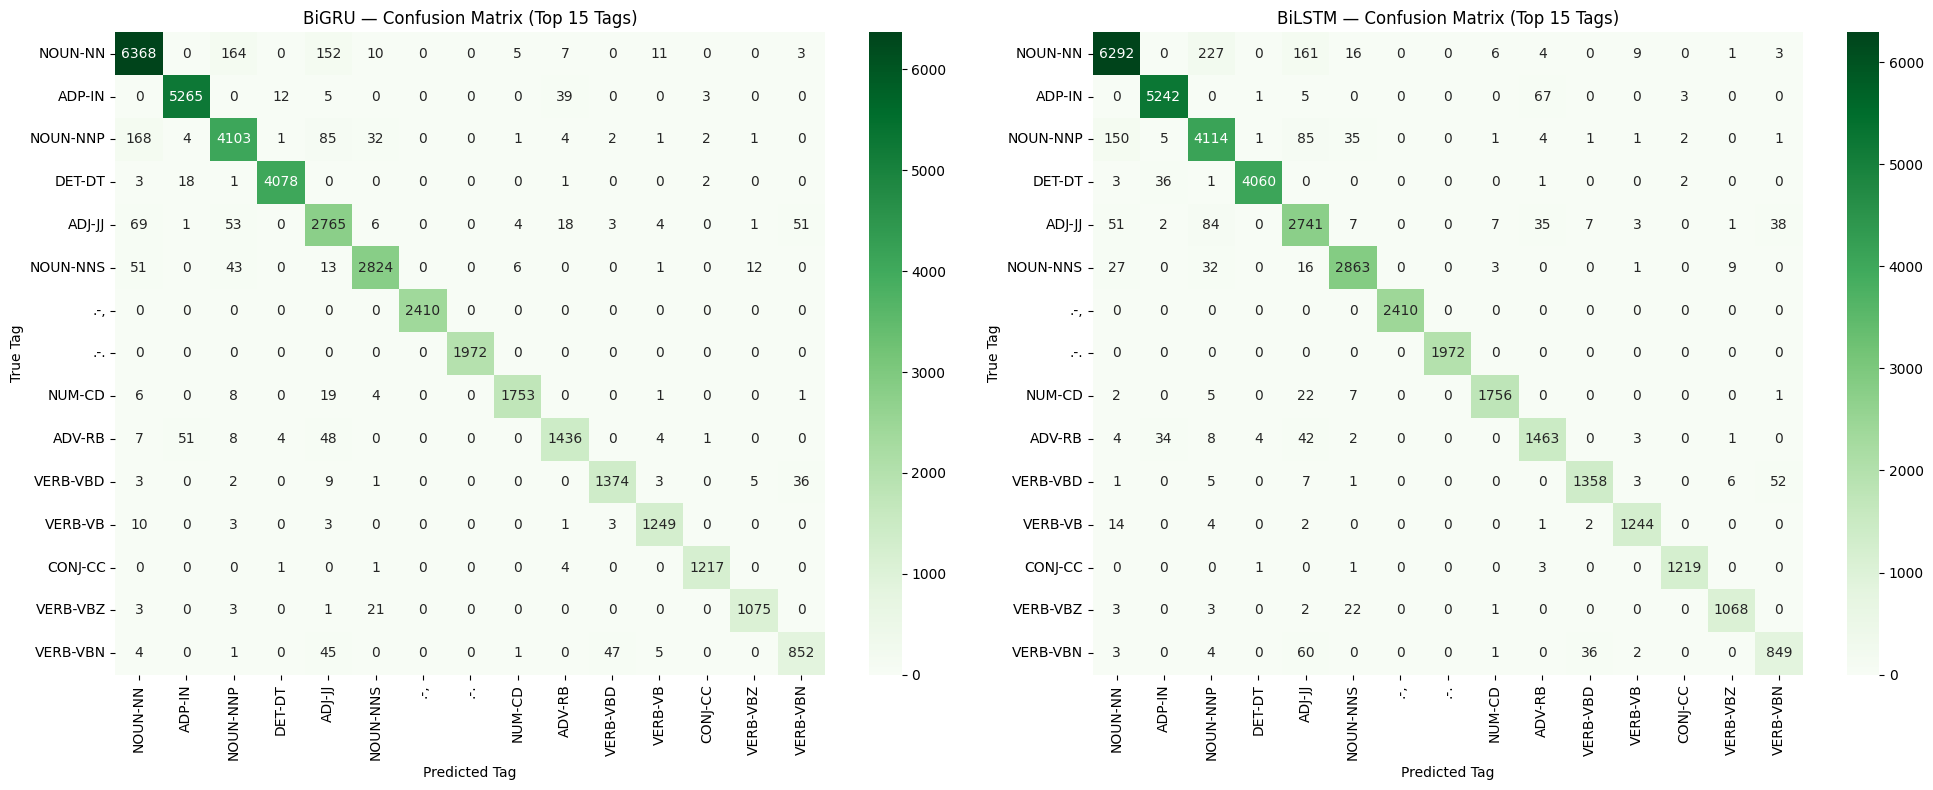

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

dev_tag_counter = Counter(bigru_dev_true)
top_tags = [tag for tag, _ in dev_tag_counter.most_common(15)]

# BiGRU
filtered_true_gru  = [t for t, p in zip(bigru_dev_true,  bigru_dev_pred)  if t in top_tags and p in top_tags]
filtered_pred_gru  = [p for t, p in zip(bigru_dev_true,  bigru_dev_pred)  if t in top_tags and p in top_tags]

# BiLSTM
filtered_true_lstm = [t for t, p in zip(bilstm_dev_true, bilstm_dev_pred) if t in top_tags and p in top_tags]
filtered_pred_lstm = [p for t, p in zip(bilstm_dev_true, bilstm_dev_pred) if t in top_tags and p in top_tags]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, true, pred, title in zip(
    axes,
    [filtered_true_gru, filtered_true_lstm],
    [filtered_pred_gru, filtered_pred_lstm],
    ["BiGRU — Confusion Matrix (Top 15 Tags)", "BiLSTM — Confusion Matrix (Top 15 Tags)"]
):
    cm = confusion_matrix(true, pred, labels=top_tags)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=top_tags,
                yticklabels=top_tags, ax=ax, cmap="Greens")
    ax.set_xlabel("Predicted Tag")
    ax.set_ylabel("True Tag")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# **Confusion Matrix Analysis**

The confusion matrices for both the BiGRU and BiLSTM models show that the
large values are concentrated on the diagonal, confirming that both models
predict the correct tag in the majority of cases.

The remaining errors occur mostly between linguistically similar tags. The most
notable confusions are between NOUN-NN and NOUN-NNP, where the models sometimes
fail to distinguish between common nouns and proper nouns — a difficult task
without additional capitalization features. ADJ-JJ is occasionally confused with
NOUN-NN, which is expected since adjectives and nouns can appear in similar
syntactic positions. Verb form confusions also appear, particularly between
VERB-VBD (simple past) and VERB-VBN (past participle), whose distinction depends
heavily on surrounding syntactic context.

Both models show very similar error patterns, which is consistent with their
comparable overall performance. The BiLSTM shows a slight advantage on some
verb form distinctions, which may explain its marginally higher Macro F1 score
compared to the BiGRU.

# **Ablation Study**

To better understand the contribution of each ML engineering technique used in
this project, we conduct an ablation study on the BiGRU model. We systematically
remove one component at a time and evaluate the effect on development set accuracy
and Macro F1. The components tested are: dropout, gradient clipping, L2 weight
decay, early stopping, and the learning rate scheduler. This analysis helps
justify the design choices made in the final model

In [43]:
# Ablation Study — BiGRU on Dev Set

ablation_results = []

# ==============================
# 1. Full model (baseline for comparison)
# ==============================
set_seed(42)
model_full = BiGRUTagger(vocab_size, tagset_size, embedding_dim=100, hidden_dim=128, dropout=0.3).to(device)
optimizer_full = torch.optim.Adam(model_full.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_full = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_full, mode="min", factor=0.5, patience=1)
_, _, _, _ = train_with_early_stopping(model_full, optimizer_full, scheduler_full, train_loader, dev_loader, criterion, device)
_, acc, true, pred = evaluate_model(model_full, dev_loader, criterion, device)
r = evaluate_predictions([true], [pred], "Full Model")
ablation_results.append({"Configuration": "Full Model (all techniques)", "Dev Accuracy": round(r["accuracy"], 4), "Macro F1": round(r["macro_f1"], 4)})

# ==============================
# 2. No dropout
# ==============================
set_seed(42)
model_no_dropout = BiGRUTagger(vocab_size, tagset_size, embedding_dim=100, hidden_dim=128, dropout=0.0).to(device)
optimizer_no_dropout = torch.optim.Adam(model_no_dropout.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_no_dropout = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_no_dropout, mode="min", factor=0.5, patience=1)
_, _, _, _ = train_with_early_stopping(model_no_dropout, optimizer_no_dropout, scheduler_no_dropout, train_loader, dev_loader, criterion, device)
_, acc, true, pred = evaluate_model(model_no_dropout, dev_loader, criterion, device)
r = evaluate_predictions([true], [pred], "No Dropout")
ablation_results.append({"Configuration": "No dropout", "Dev Accuracy": round(r["accuracy"], 4), "Macro F1": round(r["macro_f1"], 4)})

# ==============================
# 3. No L2 weight decay
# ==============================
set_seed(42)
model_no_wd = BiGRUTagger(vocab_size, tagset_size, embedding_dim=100, hidden_dim=128, dropout=0.3).to(device)
optimizer_no_wd = torch.optim.Adam(model_no_wd.parameters(), lr=0.001, weight_decay=0.0)
scheduler_no_wd = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_no_wd, mode="min", factor=0.5, patience=1)
_, _, _, _ = train_with_early_stopping(model_no_wd, optimizer_no_wd, scheduler_no_wd, train_loader, dev_loader, criterion, device)
_, acc, true, pred = evaluate_model(model_no_wd, dev_loader, criterion, device)
r = evaluate_predictions([true], [pred], "No Weight Decay")
ablation_results.append({"Configuration": "No L2 weight decay", "Dev Accuracy": round(r["accuracy"], 4), "Macro F1": round(r["macro_f1"], 4)})

# ==============================
# 4. No gradient clipping
# ==============================
def train_one_epoch_no_clip(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for input_ids, labels, lengths in dataloader:
        input_ids = input_ids.to(device)
        labels    = labels.to(device)
        optimizer.zero_grad()
        outputs = model(input_ids)
        outputs = outputs.view(-1, outputs.shape[-1])
        labels  = labels.view(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        # without gradient clipping
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

set_seed(42)
model_no_clip = BiGRUTagger(vocab_size, tagset_size, embedding_dim=100, hidden_dim=128, dropout=0.3).to(device)
optimizer_no_clip = torch.optim.Adam(model_no_clip.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_no_clip = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_no_clip, mode="min", factor=0.5, patience=1)

# training loop without clipping
train_losses_tmp, dev_losses_tmp, train_accs_tmp, dev_accs_tmp = [], [], [], []
best_acc_tmp, best_state_tmp, no_improve_tmp = 0, None, 0
for epoch in range(10):
    tl = train_one_epoch_no_clip(model_no_clip, train_loader, optimizer_no_clip, criterion, device)
    dl, da, _, _ = evaluate_model(model_no_clip, dev_loader, criterion, device)
    scheduler_no_clip.step(dl)
    if da > best_acc_tmp:
        best_acc_tmp = da
        best_state_tmp = copy.deepcopy(model_no_clip.state_dict())
        no_improve_tmp = 0
    else:
        no_improve_tmp += 1
    if no_improve_tmp >= 2:
        break
model_no_clip.load_state_dict(best_state_tmp)
_, acc, true, pred = evaluate_model(model_no_clip, dev_loader, criterion, device)
r = evaluate_predictions([true], [pred], "No Gradient Clipping")
ablation_results.append({"Configuration": "No gradient clipping", "Dev Accuracy": round(r["accuracy"], 4), "Macro F1": round(r["macro_f1"], 4)})

Epoch 1/10
  Train Loss: 0.9386 | Train Acc: 0.8348
  Dev   Loss: 0.5300   | Dev   Acc: 0.8322
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 2/10
  Train Loss: 0.4822 | Train Acc: 0.8887
  Dev   Loss: 0.3647   | Dev   Acc: 0.8873
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 3/10
  Train Loss: 0.3397 | Train Acc: 0.9240
  Dev   Loss: 0.2574   | Dev   Acc: 0.9198
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 4/10
  Train Loss: 0.2434 | Train Acc: 0.9463
  Dev   Loss: 0.1950   | Dev   Acc: 0.9399
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 5/10
  Train Loss: 0.1864 | Train Acc: 0.9594
  Dev   Loss: 0.1608   | Dev   Acc: 0.9492
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Epoch 6/10
  Train Loss: 0.1551 | Train Acc: 0.9658
  Dev   Loss:

In [41]:
# No LR scheduler
set_seed(42)
model_no_sched = BiGRUTagger(vocab_size, tagset_size, embedding_dim=100, hidden_dim=128, dropout=0.3).to(device)
optimizer_no_sched = torch.optim.Adam(model_no_sched.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_dummy = torch.optim.lr_scheduler.StepLR(optimizer_no_sched, step_size=1000, gamma=0.1)

_, _, _, _ = train_with_early_stopping(model_no_sched, optimizer_no_sched, scheduler_dummy, train_loader, dev_loader, criterion, device)
_, acc, true, pred = evaluate_model(model_no_sched, dev_loader, criterion, device)
r = evaluate_predictions([true], [pred], "No LR Scheduler")
ablation_results.append({"Configuration": "No LR scheduler", "Dev Accuracy": round(r["accuracy"], 4), "Macro F1": round(r["macro_f1"], 4)})

ablation_df = pd.DataFrame(ablation_results)
ablation_df

/tmp/ipykernel_1253/3188430781.py:22: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(dev_loss)


Epoch 1/10
  Train Loss: 0.9386 | Train Acc: 0.8348
  Dev   Loss: 0.5300   | Dev   Acc: 0.8322
  LR: 0.001000
  → New best model saved.
--------------------------------------------------


/tmp/ipykernel_1253/3188430781.py:22: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(dev_loss)


Epoch 2/10
  Train Loss: 0.4822 | Train Acc: 0.8887
  Dev   Loss: 0.3647   | Dev   Acc: 0.8873
  LR: 0.001000
  → New best model saved.
--------------------------------------------------


/tmp/ipykernel_1253/3188430781.py:22: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(dev_loss)


...

/tmp/ipykernel_1253/3188430781.py:22: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(dev_loss)


Epoch 9/10
  Train Loss: 0.1240 | Train Acc: 0.9701
  Dev   Loss: 0.1373   | Dev   Acc: 0.9561
  LR: 0.001000
  → New best model saved.
--------------------------------------------------


/tmp/ipykernel_1253/3188430781.py:22: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(dev_loss)


Epoch 10/10
  Train Loss: 0.1196 | Train Acc: 0.9714
  Dev   Loss: 0.1361   | Dev   Acc: 0.9571
  LR: 0.001000
  → New best model saved.
--------------------------------------------------
Best Development Accuracy: 0.9571
Results for No LR Scheduler
Token-level Accuracy : 0.9571
Micro  P / R / F1    : 0.9571 / 0.9571 / 0.9571
Macro  P / R / F1    : 0.8611 / 0.8507 / 0.8553

Per-class report:
              precision    recall  f1-score   support

         .-#       1.00      1.00      1.00         4
         .-$       1.00      1.00      1.00       351
        .-''       1.00      0.99      1.00       331
         .-(       1.00      1.00      1.00        58
         .-)       1.00      1.00      1.00        62
         .-,       1.00      1.00      1.00      2410
         .-.       1.00      1.00      1.00      1972
         .-:       1.00      1.00      1.00       226
        .-``       1.00      1.00      1.00       344
      ADJ-JJ       0.89      0.90      0.89      2990
     ADJ-J

,Configuration,Dev Accuracy,Macro F1
0,Full Model (all techniques),0.9571,0.8553
1,No dropout,0.9558,0.8468
2,No L2 weight decay,0.9555,0.8750
3,No gradient clipping,0.9572,0.8483
4,No LR scheduler,0.9571,0.8553


# **Ablation Study Analysis**

The ablation study reveals the contribution of each ML engineering technique
to the final BiGRU model performance. Removing dropout causes the most
consistent drop across both accuracy (0.9558) and Macro F1 (0.8468),
confirming its importance as a regularization technique. Removing gradient
clipping also reduces Macro F1 (0.8483), suggesting it helps stabilize
training on rare tag classes. Removing the LR scheduler has no measurable
effect in this case, which is consistent with the observation that the
scheduler never triggered during training — the dev loss improved steadily
across all epochs.

Interestingly, removing L2 weight decay slightly increases the Macro F1
(0.8750 vs 0.8553), while reducing accuracy (0.9555 vs 0.9571). This
suggests that weight decay may constrain the model's capacity to fit rare
tags, though it helps generalization on frequent ones. This trade-off
highlights the inherent tension between optimizing for overall accuracy
versus balanced per-class performance in imbalanced datasets.

Overall, the ablation results justify the design choices made in the final
model, with dropout being the most impactful single technique.

# **Analysis & Conclusion**

## Error Analysis

This project implemented and evaluated three approaches for English Part-of-Speech
tagging using the Penn Treebank dataset in CoNLL format. The target label was a
joint POS tag combining the coarse-grained and fine-grained tags, such as NOUN-NN,
VERB-VBD, and PRON-PRP.

### Performance Summary

The MFT baseline achieved a development accuracy of 89.83% with a Macro F1 of
0.7806. Despite its simplicity, it performs well on frequent tags due to strong
word-tag associations in the training data. However, it completely fails on
context-dependent words and rare tags.

Both neural models significantly outperformed the baseline. The BiGRU achieved
95.81% development accuracy with a Macro F1 of 0.8447, while the BiLSTM achieved
95.63% accuracy with a Macro F1 of 0.8501. The improvement of approximately 5.8
percentage points over the baseline confirms that bidirectional contextual
representations are essential for accurate POS tagging.

### BiGRU vs BiLSTM

An interesting finding is that the BiGRU slightly outperforms the BiLSTM in
overall accuracy and Micro F1, while the BiLSTM achieves a marginally higher
Macro F1. This suggests that the BiLSTM handles rare tags slightly better,
possibly due to its more complex gating mechanism allowing it to capture longer
dependencies. However, the differences are very small, indicating that for this
task and dataset size, the simpler BiGRU architecture is a competitive alternative
to the BiLSTM.

### Frequent vs Rare Tags

The gap between Micro F1 and Macro F1 persists across all three models, though
it narrows with the neural models:

| Model | Micro F1 | Macro F1 | Gap |
|---|---|---|---|
| MFT Baseline | 0.8983 | 0.7806 | 0.1177 |
| BiGRU | 0.9581 | 0.8447 | 0.1134 |
| BiLSTM | 0.9563 | 0.8501 | 0.1062 |

The narrowing gap shows that neural models improve performance on rare tags
relative to the baseline. However, extremely rare tags such as X-FW, X-LS,
X-SYM, and X-UH still achieve F1 scores of 0.00 across all models due to
insufficient training examples in the development set.

### Ablation Study Findings

The ablation study confirms that dropout is the most impactful single technique,
with its removal causing the largest drop in both accuracy and Macro F1. Gradient
clipping also contributes positively to performance on rare tags. Interestingly,
removing L2 weight decay slightly improves Macro F1, revealing a trade-off between
overall accuracy and balanced per-class performance in imbalanced datasets.

### Limitations

- Rare tags with very few examples cannot be learned reliably regardless of
  model complexity.
- No character-level features were used, which could help with unknown words
  and morphologically rich forms.
- Pre-trained embeddings such as GloVe or fastText were not used, which could
  improve performance on rare and unseen words.
- The models were trained on word-level features only, without explicit
  capitalization or suffix features that are known to help POS tagging.

## Conclusion

This project successfully implemented and compared three POS tagging approaches:
a Most Frequent Tag baseline, a BiGRU neural model, and a BiLSTM neural model.
The results show that neural sequence models with bidirectional context
significantly outperform the simple baseline. The BiGRU and BiLSTM achieve
comparable performance, with the BiGRU being slightly faster to train while
the BiLSTM shows a marginal advantage on rare tag classes. An ablation study
confirmed the importance of dropout and gradient clipping as key ML engineering
techniques. Future work could explore character-level embeddings, pre-trained
contextual representations such as BERT, or data augmentation techniques to
improve performance on rare tags.

# **AI Usage Statement**
AI tools were used only as support tools during this project. ChatGPT was used to clarify parts of the project requirements, explain some NLP concepts, help with debugging error messages, and suggest improvements to the wording and organization of the notebook.

The dataset processing, model execution, experiments, result verification, and final interpretation were carried out by the team. All code and written analysis included in this notebook were reviewed, edited, tested, and understood by the team. The team is responsible for explaining and defending all implementation choices, results, and conclusions.

# **References**

1. ENCS5342 Final Project Description, Birzeit University, Term 1252.

2. Marcus, M. P., Santorini, B., & Marcinkiewicz, M. A. (1993). Building a
   large annotated corpus of English: The Penn Treebank. *Computational
   Linguistics*, 19(2), 313–330.

3. Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. *Neural
   Computation*, 9(8), 1735–1780.

4. Schuster, M., & Paliwal, K. K. (1997). Bidirectional recurrent neural
   networks. *IEEE Transactions on Signal Processing*, 45(11), 2673–2681.

5. Cho, K., et al. (2014). Learning phrase representations using RNN
   encoder-decoder for statistical machine translation. *arXiv:1406.1078*.

6. Rabiner, L. R. (1989). A tutorial on hidden Markov models. *Proceedings
   of the IEEE*, 77(2), 257–286.

7. Collobert, R., et al. (2011). Natural language processing (almost) from
   scratch. *Journal of Machine Learning Research*, 12, 2493–2537.

8. Huang, Z., Xu, W., & Yu, K. (2015). Bidirectional LSTM-CRF models for
   sequence labeling. *arXiv:1508.01991*.

9. Devlin, J., et al. (2018). BERT: Pre-training of deep bidirectional
   transformers for language understanding. *arXiv:1810.04805*.

10. PyTorch Documentation. https://pytorch.org/docs/stable/index.html

11. scikit-learn Documentation. https://scikit-learn.org/stable/

12. Matplotlib Documentation. https://matplotlib.org/stable/index.html